In [ ]:
!pip install torch torchvision scikit-learn matplotlib numpy -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/lens-finding-test.zip'

# extracting zip
import zipfile, os
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content/dataset')

# verify folders
for d in ['train_lenses','train_nonlenses','test_lenses','test_nonlenses']:
    path = f'/content/dataset/{d}'
    files = os.listdir(path)
    print(f"{d}: {len(files)} files")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train_lenses: 1730 files
train_nonlenses: 28675 files
test_lenses: 195 files
test_nonlenses: 19455 files


In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torch.optim as optim
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device:', device)

using device: cpu


In [5]:
class GalaxyDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir, augment=False):

        lens_files    = sorted(glob.glob(os.path.join(lens_dir, '*.npy')))
        nonlens_files = sorted(glob.glob(os.path.join(nonlens_dir, '*.npy')))

        self.files  = lens_files + nonlens_files
        self.labels = [1] * len(lens_files) + [0] * len(nonlens_files)
        self.augment = augment

        print(f'lenses: {len(lens_files)}, non-lenses: {len(nonlens_files)}')

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(90),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx]).astype(np.float32)  # shape (3, 64, 64)

        # normalize each channel to [0, 1]
        for c in range(img.shape[0]):
            mn, mx = img[c].min(), img[c].max()
            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)

        img = torch.tensor(img)

        if self.augment:
            img = transforms.ToPILImage()(img)
            img = self.aug(img)
            img = transforms.ToTensor()(img)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

In [15]:
!cp -r /content/dataset /content/local_data

In [23]:
train_dataset = GalaxyDataset('/content/local_data/train_lenses',
                             '/content/local_data/train_nonlenses', augment=True)

test_dataset = GalaxyDataset('/content/local_data/test_lenses',
                            '/content/local_data/test_nonlenses', augment=False)

train_dataset.files = train_dataset.files[:3000]
train_dataset.labels = train_dataset.labels[:3000]

# handle class imbalance with weighted sampler
labels = np.array(train_dataset.labels)
n_pos  = labels.sum()
n_neg  = len(labels) - n_pos
weights = np.where(labels == 1, 1.0/n_pos, 1.0/n_neg)
sampler = WeightedRandomSampler(torch.tensor(weights, dtype=torch.float32),
                                 num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32,
                          sampler=sampler,
                          num_workers=2,
                          pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False,
                         num_workers=2,
                         pin_memory=True)

print('train batches:', len(train_loader))
print('test batches: ', len(test_loader))

lenses: 1730, non-lenses: 28675
lenses: 195, non-lenses: 19455
train batches: 94
test batches:  615


In [24]:
# using pretrained efficientnet and replacing the last layer
# 3 input channels match the 3 filter images

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 1)
)

model = model.to(device)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [25]:
# pos_weight tells the loss to penalize missing a lens more
# because there are way more non-lenses than lenses
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
print('pos_weight:', pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr = 3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

pos_weight: 0.7341040462427746


In [26]:
for i, (imgs, labels) in enumerate(train_loader):
    print("First batch loaded in", i)
    break

First batch loaded in 0


In [27]:
epochs = 5
best_val_loss = float('inf')

train_losses = []
val_losses = []

print("Training started...")

for epoch in range(1, epochs + 1):

    # training
    model.train()
    running_loss = 0

    for i, (imgs, labels) in enumerate(train_loader):
        if i % 100 == 0:
            print(f"Batch {i}/{len(train_loader)}")
        imgs = imgs.to(device)
        labels = labels.to(device).float().view(-1)

        optimizer.zero_grad()

        outputs = model(imgs).view(-1)
        loss = criterion(outputs, labels)

        if torch.isnan(loss):
            print("NaN loss detected, stopping training")
            break

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / max(len(train_loader), 1)
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).float().view(-1)

            outputs = model(imgs).view(-1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.3).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / max(len(test_loader), 1)
    val_losses.append(val_loss)

    # accuracy
    acc = (np.array(all_preds) == np.array(all_labels)).mean()

    scheduler.step()

    print(f"Epoch {epoch}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {acc:.4f}")
    print("-----------------------------")

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model saved\n")

print("Training finished")

Training started...
Batch 0/94
Epoch 1/5
Train Loss: 0.3402
Validation Loss: 0.2595
Validation Accuracy: 0.8153
-----------------------------
Best model saved

Batch 0/94
Epoch 2/5
Train Loss: 0.2170
Validation Loss: 0.3245
Validation Accuracy: 0.7595
-----------------------------
Batch 0/94
Epoch 3/5
Train Loss: 0.1927
Validation Loss: 0.3683
Validation Accuracy: 0.6419
-----------------------------
Batch 0/94
Epoch 4/5
Train Loss: 0.1832
Validation Loss: 0.3559
Validation Accuracy: 0.7591
-----------------------------
Batch 0/94
Epoch 5/5
Train Loss: 0.1655
Validation Loss: 0.3811
Validation Accuracy: 0.7627
-----------------------------
Training finished


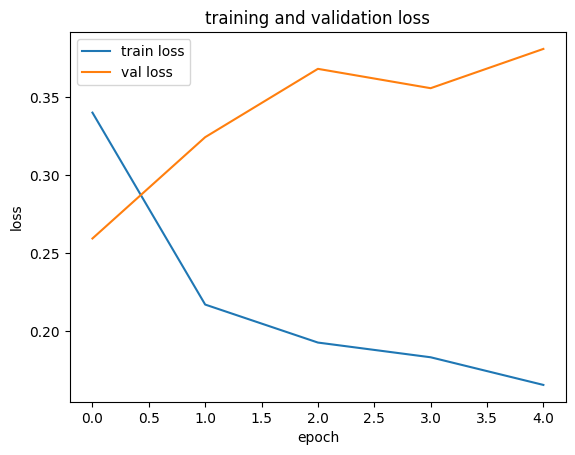

In [28]:
plt.plot(train_losses, label='train loss')
plt.plot(val_losses,   label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation loss')
plt.legend()
plt.show()

In [29]:
# predictions on test data
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out  = model(imgs).squeeze(1)
        probs = torch.sigmoid(out).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

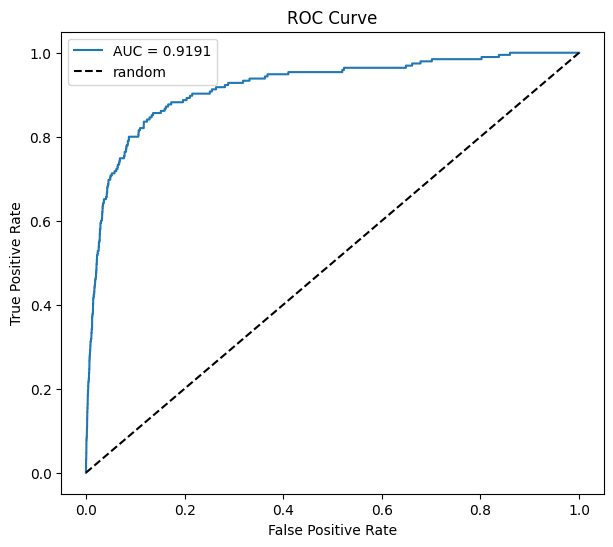

AUC score: 0.9191


In [30]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f'AUC score: {roc_auc:.4f}')

In [31]:
# classification report
best_idx = np.argmax(tpr - fpr)
best_thr = thresholds[best_idx]
print(f'best threshold: {best_thr:.3f}')

preds = (all_probs >= best_thr).astype(int)
print(classification_report(all_labels, preds, target_names=['non-lens', 'lens']))

preds = (all_probs >= best_thr).astype(int)
print(classification_report(all_labels, preds, target_names=['non-lens', 'lens']))

best threshold: 0.368
              precision    recall  f1-score   support

    non-lens       1.00      0.86      0.93     19455
        lens       0.06      0.86      0.11       195

    accuracy                           0.86     19650
   macro avg       0.53      0.86      0.52     19650
weighted avg       0.99      0.86      0.92     19650

              precision    recall  f1-score   support

    non-lens       1.00      0.86      0.93     19455
        lens       0.06      0.86      0.11       195

    accuracy                           0.86     19650
   macro avg       0.53      0.86      0.52     19650
weighted avg       0.99      0.86      0.92     19650

